In [1]:
import os 
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
import itertools
from scipy.stats import wilcoxon
def barplot_annotate_brackets(num1, num2, data, center, height, ax, yerr=None, dh=.05, barh=.05, fs=None, maxasterix=None):
    if type(data) is str:
        text = data
    else:
        if data > 0.05:
          return
        # * is p < 0.05
        # ** is p < 0.005
        # *** is p < 0.0005
        # etc.
        text = ''
        p = .05

        while data < p:
            text += '*'
            p /= 10.

            if maxasterix and len(text) == maxasterix:
                break

        if len(text) == 0:
            text = 'n. s.'

    lx, ly = center[num1], height[num1]
    rx, ry = center[num2], height[num2]

    if yerr:
        ly += yerr[num1]
        ry += yerr[num2]

    ax_y0, ax_y1 = plt.gca().get_ylim()
    dh *= (ax_y1 - ax_y0)
    barh *= (ax_y1 - ax_y0)

    y = max(ly, ry) + dh

    barx = [lx, lx, rx, rx]
    bary = [y, y+barh, y+barh, y]
    mid = ((lx+rx)/2, y+barh)

    ax.plot(barx, bary, c='black')

    kwargs = dict(ha='center', va='bottom')
    if fs is not None:
        kwargs['fontsize'] = fs

    ax.text(*mid, text, **kwargs)

In [3]:
path=r"C:\Users\Pc\Documents\Tese\written"

In [4]:
excel_file="windowed_results_f.xlsx"
# Read Excel Files 
path_excel = os.path.join(path, excel_file)
data = pd.read_excel(path_excel)

print(data.head())


   ID  Balancing    TP   FP    FN    TN
0   6        1.0   906   67  2150  2978
1   6        1.0   630   48  2426  2997
2   6        1.0  1651  180  1405  2865
3   6        1.0  1629  172  1427  2873
4   6        1.0  1809  340  1247  2405


In [5]:
def compute_classification_metrics(df):
    df = df.copy()  # Avoid modifying original

    df["Accuracy"] = (df["TP"] + df["TN"]) / (df["TP"] + df["FP"] + df["FN"] + df["TN"])
    df["Precision"] = df["TP"] / (df["TP"] + df["FP"])
    df["Recall"] = df["TP"] / (df["TP"] + df["FN"])
    # df["Specificity"] = df["TN"] / (df["TN"] + df["FP"])
    df["F1"] = 2 * df["Precision"] * df["Recall"] / (df["Precision"] + df["Recall"])

    return df

data_metrics = compute_classification_metrics(data)
# Show by balance
balance = [0.5, 1, 2, 3]
for b in balance:
    data_b = data_metrics[data_metrics['Balancing'] == b]
    print(data_b)

     ID  Balancing    TP    FP    FN    TN  Accuracy  Precision    Recall  \
82   12        0.5  1195  6011  1841    49  0.136763   0.165834  0.393610   
83   12        0.5  1202  6010  1834    50  0.137643   0.166667  0.395916   
84   12        0.5  1207   125  1829  5935  0.785180   0.906156  0.397563   
85   12        0.5   945    81  2091  5979  0.761214   0.921053  0.311265   
86   12        0.5  1523   242  1513  5818  0.807058   0.862890  0.501647   
87   12        0.5  1592   441  1444  5619  0.792766   0.783079  0.524374   
88   12        0.5  1680   979  1356  5081  0.743294   0.631816  0.553360   
89   12        0.5     7     5  3029  6055  0.666447   0.583333  0.002306   
90   12        0.5  1839   804  1197  5256  0.780013   0.695800  0.605731   
91   12        0.5    89     2  2947  6058  0.675792   0.978022  0.029315   
92   12        0.5  1513   406  1523  5654  0.787929   0.788431  0.498353   
93   12        0.5   643    75  2393  5985  0.728672   0.895543  0.211792   

In [6]:
curr_dir=os.getcwd()
# --- LOAD THE .pkl FILE GENERATED PREVIOUSLY ---
adapt=20
test_ds_b4=False
if test_ds_b4:
    identifier=f"testing_dsb4_adaptable{adapt}" if adapt > 0 else "testing_dsb4"
else:
    identifier=f"30000_1000_100_adaptable{adapt}" if adapt > 0 else "30000_1000_100"
    # identifier="1000_200_median"

dataset_colors={
   "Amigo": "#8E44AD",
   "Dlx": "#E74C3C",
   "Som": "#FFC300",
   "Thy": "#17BECF"
}

In [7]:
filename= f"channel_metrics_by_network_{identifier}.csv"
results_df= pd.read_csv(os.path.join(curr_dir, filename))
print(f"Results loaded from {os.path.join(curr_dir, filename)}")
print(results_df.head())

Results loaded from c:\Users\Pc\Documents\Tese\LAVA_SNN_ripples\snnTorch\analysis\channel_metrics_by_network_30000_1000_100_adaptable20.csv
                   Network                     Dataset  Channel   TP   FP  FN  \
0  dsb4updn_median_200_15f  Amigo2_2019-07-11_11-57-07        0  196  301  28   
1  dsb4updn_median_200_15f  Amigo2_2019-07-11_11-57-07        1  190  262  34   
2  dsb4updn_median_200_15f  Amigo2_2019-07-11_11-57-07        2  170  172  54   
3  dsb4updn_median_200_15f  Amigo2_2019-07-11_11-57-07        3  158  169  66   
4  dsb4updn_median_200_15f  Amigo2_2019-07-11_11-57-07        4  133  150  91   

   Precision    Recall        F1  
0   0.394366  0.875000  0.543689  
1   0.420354  0.848214  0.562130  
2   0.497076  0.758929  0.600707  
3   0.483180  0.705357  0.573503  
4   0.469965  0.593750  0.524655  


In [8]:
def prepare_comparison_data(data_metrics, results_df, balances,
                            metrics=["Precision","Recall","F1"],
                            group="channel"):
    """
    Prepare data for Windowed vs Continuous comparison.

    Parameters
    ----------
    data_metrics : DataFrame
        From excel file, already computed with classification metrics.
    results_df : DataFrame
        Continuous results (channel-level).
    balances : list
        Balancing values to include from data_metrics.
    metrics : list
        Which metrics to extract.
    group : str
        "channel" : raw results_df rows
        "dataset" : average across channels per (Network, Dataset)
        "network" : average across datasets per Network
    """

    # --- Windowed (select balances) ---
    win = data_metrics[data_metrics["Balancing"].isin(balances)].copy()
    win = win[metrics]
    win["Source"] = "Windowed"

    # --- Continuous (depending on grouping) ---
    if group == "channel":
        cont = results_df.copy()
        cont = cont[metrics]
        cont["Source"] = "Continuous"

    elif group == "dataset":
        cont = results_df.groupby(["Network", "Dataset"])[metrics].mean().reset_index()
        cont = cont[metrics]
        cont["Source"] = "Continuous"

    elif group == "network":
        cont = results_df.groupby("Network")[metrics].mean().reset_index()
        cont = cont[metrics]
        cont["Source"] = "Continuous"

    else:
        raise ValueError("group must be 'channel', 'dataset', or 'network'")

    return pd.concat([win, cont], ignore_index=True)


In [10]:
df=prepare_comparison_data(data_metrics, results_df, balances=[2,3,1,0.5],
                           metrics=["Precision","Recall","F1"],
                           group="dataset")
df.head()

,Precision,Recall,F1,Source
0,0.931141,0.296466,0.449739,Windowed
1,0.929204,0.206152,0.337440,Windowed
2,0.901693,0.540249,0.675670,Windowed
3,0.904498,0.533050,0.670784,Windowed
4,0.841787,0.591950,0.695101,Windowed


In [9]:
from matplotlib.patches import Patch
from scipy.stats import mannwhitneyu

# -------------------------
# Holm–Bonferroni correction
# -------------------------
def holm_bonferroni(p_values, alpha=0.05):
    """Apply Holm–Bonferroni correction to a list of p-values."""
    m = len(p_values)
    sorted_indices = np.argsort(p_values)
    sorted_pvals = np.array(p_values)[sorted_indices]
    reject = np.zeros(m, dtype=bool)
    adjusted_pvals = np.zeros(m)

    for k, p in enumerate(sorted_pvals):
        threshold = alpha / (m - k)
        if p <= threshold:
            reject[sorted_indices[k]] = True
        adjusted_pvals[sorted_indices[k]] = min(p * (m - k), 1.0)

    return adjusted_pvals, reject


In [17]:
def plot_windowed_vs_continuous(comp_df, metrics=["Precision","Recall","F1"],
                                colors=None, back_colors=None):
    fig, ax = plt.subplots(figsize=(8,6))

    if colors is None:
        colors = {
            "Windowed": "#E67E22",   # warm orange
            "Continuous": "#2980B9"  # rich blue
        }
    if back_colors is None:
        back_colors = {
            "Precision": "lightblue",
            "Recall": "lightgreen",
            "F1": "lightcoral"
        }

    width = 0.8
    spacing = 2
    positions, data, plot_colors = [], [], []
    xticks, xtick_labels = [], []

    # --- Collect data and add backcolumn shading ---
    for i, metric in enumerate(metrics):
        base_pos = i * (2 + spacing)   # two groups: Windowed, Continuous

        # Background shading across the two bars of this metric
        ax.axvspan(base_pos - 0.8,
                   base_pos + 2 - 0.3,  # span over 2 groups
                   color=back_colors.get(metric, "lightgray"),
                   alpha=0.15, zorder=0)

        for j, source in enumerate(["Windowed", "Continuous"]):
            vals = comp_df[comp_df["Source"] == source][metric].dropna().values
            pos = base_pos + j
            positions.append(pos)
            data.append(vals)
            plot_colors.append(colors[source])

        xticks.append(base_pos + 0.5)
        xtick_labels.append(metric)

    # --- Draw boxplots ---
    box_heights = []
    for pos, vals, c in zip(positions, data, plot_colors):
        bplot = ax.boxplot(vals, positions=[pos], widths=width, patch_artist=True,
                           showfliers=False, medianprops=dict(color='black'))
        for patch in bplot['boxes']:
            patch.set_facecolor(c)
        box_heights.append(np.max(vals) if len(vals) > 0 else 0)

    # --- Stats: Windowed vs Continuous for each metric ---
    for i, metric in enumerate(metrics):
        idx_a, idx_b = i*2, i*2+1
        vals_a, vals_b = data[idx_a], data[idx_b]

        if len(vals_a) == 0 or len(vals_b) == 0:
            continue

        try:
            _, p = mannwhitneyu(vals_a, vals_b, alternative="two-sided")
        except ValueError:
            print(f"Not enough data for {metric} comparison.")
            continue

        # Holm–Bonferroni correction
        adj_pvals, _ = holm_bonferroni([p], alpha=0.05)
        adj_p = adj_pvals[0]

        # Annotate
        barplot_annotate_brackets(idx_a, idx_b, adj_p,
                                  positions, box_heights, ax,
                                  dh=0.05, barh=0.0, fs=12,maxasterix=3)

    # --- Formatting ---
    ax.set_xticks(xticks)
    ax.set_xticklabels(xtick_labels, fontsize=14)
    ax.tick_params(axis='both', labelsize=14,width=2)
    ax.set_ylabel("Score", fontsize=14)
    # ax.set_title("Windowed vs Continuous", fontsize=16)
    ax.grid(True, linestyle="--", alpha=0.5)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.set_ylim(0, 1.10)
    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)

    # legend_handles = [Patch(facecolor=colors[s], label=s) for s in ["Windowed", "Continuous"]]
    # ax.legend(handles=legend_handles, title="Source", fontsize=14)

    plt.tight_layout()
    return fig, ax


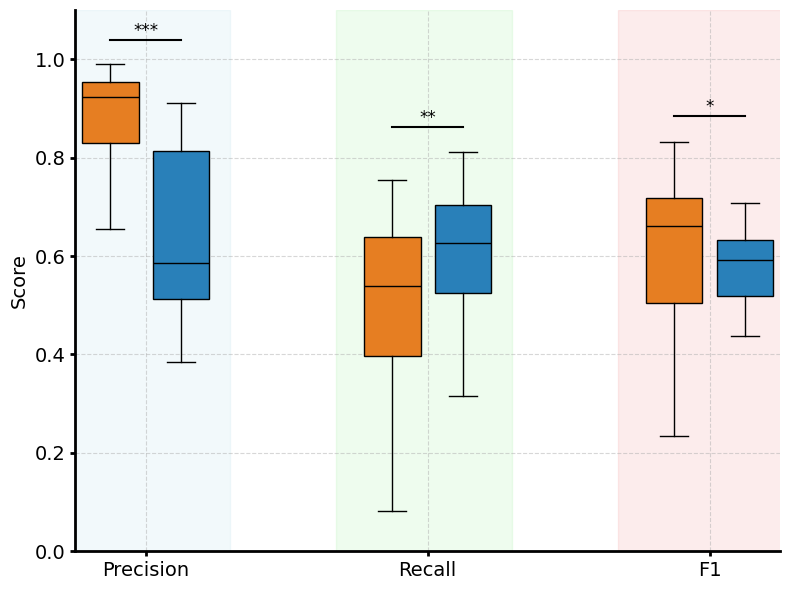

In [18]:
fig,ax=plot_windowed_vs_continuous(df, metrics=["Precision","Recall","F1"],
                                colors=None)

fig.savefig("figures/windowed_vs_continuous_adaptable20.svg", dpi=500)